In [1]:
!pip install scikit-learn pandas numpy matplotlib joblib

  Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached pandas-3.0.5-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\khaoula\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
import joblib
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay, precision_recall_fscore_support)
import matplotlib.pyplot as plt

In [3]:
# 1. CHARGEMENT DES DONNÉES
print("Chargement des données en cours...")
X_train, X_test, y_train, y_test = joblib.load("../models/train_test_data.pkl")
X_train_scaled, X_test_scaled = joblib.load("../models/scaled_data.pkl")

Chargement des données en cours...


In [4]:
# 2. ENTRAÎNEMENT DE L'ISOLATION FOREST
print("\n--- Entraînement de l'Isolation Forest ---")
# Filtre : On n'apprend que sur le trafic normal (BENIGN)
X_train_benign = X_train_scaled[y_train.values == "BENIGN"]

# Initialisation (contamination fixée à 5% d'anomalies supposées dans le test)
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)
iso.fit(X_train_benign)


--- Entraînement de l'Isolation Forest ---


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)



--- Isolation Forest Report ---
              precision    recall  f1-score   support

      ATTACK       0.75      0.35      0.47    106090
      BENIGN       0.77      0.95      0.85    249697

    accuracy                           0.77    355787
   macro avg       0.76      0.65      0.66    355787
weighted avg       0.77      0.77      0.74    355787



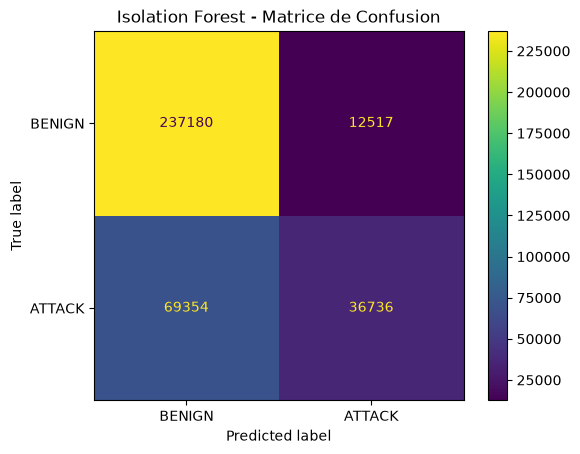

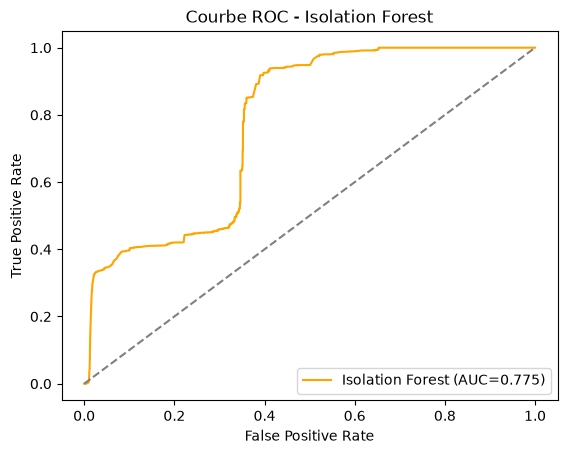

Modèle Isolation Forest sauvegardé !


In [5]:
# 3. PRÉDICTIONS ET ÉVALUATION
# ==========================================
# IF renvoie 1 (Normal) et -1 (Anomalie)
y_pred_iso_raw = iso.predict(X_test_scaled)
y_pred_iso = pd.Series(y_pred_iso_raw).map({1: "BENIGN", -1: "ATTACK"})
scores_iso = iso.decision_function(X_test_scaled) # Scores continus

print("\n--- Isolation Forest Report ---")
print(classification_report(y_test, y_pred_iso))

# Matrice de confusion
cm_iso = confusion_matrix(y_test, y_pred_iso, labels=["BENIGN", "ATTACK"])
ConfusionMatrixDisplay(cm_iso, display_labels=["BENIGN", "ATTACK"]).plot()
plt.title("Isolation Forest - Matrice de Confusion")
# plt.savefig("../../docs/architecture/iso_confusion_matrix.png") # Décommenter pour sauvegarder
plt.show()

# Courbe ROC (Score inversé car plus il est bas, plus c'est anormal)
y_test_num = y_test.map({"BENIGN": 0, "ATTACK": 1})
fpr_iso, tpr_iso, _ = roc_curve(y_test_num, -scores_iso)  
auc_iso = roc_auc_score(y_test_num, -scores_iso)

plt.figure()
plt.plot(fpr_iso, tpr_iso, label=f"Isolation Forest (AUC={auc_iso:.3f})", color='orange')
plt.plot([0,1],[0,1],"--", color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Isolation Forest")
plt.legend()
# plt.savefig("../../docs/architecture/iso_roc_curve.png") # Décommenter pour sauvegarder
plt.show()

joblib.dump(iso, "../models/isolation_forest_v1.pkl")
print("Modèle Isolation Forest sauvegardé !")

In [10]:
# 4. TABLEAU DE COMPARAISON FINAL (RF vs IF)
# ==========================================
print("\n--- Génération du tableau comparatif ---")
# On recharge le Random Forest pour comparer
rf = joblib.load("../models/random_forest_v1.pkl")
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 0]
auc_rf = roc_auc_score(y_test_num, y_proba_rf)

# Extraction automatique des métriques pour la classe "ATTACK"
prec_rf, rec_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, labels=["ATTACK"])
prec_iso, rec_iso, f1_iso, _ = precision_recall_fscore_support(y_test, y_pred_iso, labels=["ATTACK"])

results = pd.DataFrame({
    "Modèle": ["Random Forest (Supervisé)", "Isolation Forest (Non-Supervisé)"],
    "Précision": [prec_rf[0], prec_iso[0]],
    "Rappel":    [rec_rf[0], rec_iso[0]],
    "F1-score":  [f1_rf[0], f1_iso[0]],
    "AUC-ROC":   [auc_rf, auc_iso],
})

# Arrondir à 3 décimales pour un affichage propre
results = results.round(3)
print(results)

# Sauvegarde pour le rapport
results.to_csv("../models/ml-results-comparison.csv", index=False)
print("\nTableau sauvegardé sous 'models/ml-results-comparison.csv'")


--- Génération du tableau comparatif ---
                             Modèle  Précision  Rappel  F1-score  AUC-ROC
0         Random Forest (Supervisé)      0.956   0.988     0.972    0.998
1  Isolation Forest (Non-Supervisé)      0.746   0.346     0.473    0.775

Tableau sauvegardé sous 'models/ml-results-comparison.csv'
